In [1]:
import csv
import pandas as pd
import numpy as np

In [2]:
raw_df = pd.read_csv(
    "experiment_data.csv", 
    delimiter='\t', 
    names=['client_labda','server_mu', 'alpha', 'active_servers_num', 'run_iterations', 'request_id', 'server_processing_time_ideal', 
           'time_untill_next_client', 'sent_is_cpu','client_measured_time','server_processing_time_measured', 'is_cpu_received'], 
    header=None
)
raw_df.head()

,client_labda,server_mu,alpha,active_servers_num,run_iterations,request_id,server_processing_time_ideal,time_untill_next_client,sent_is_cpu,client_measured_time,server_processing_time_measured,is_cpu_received
0,0.3,1,0.1,1,500,0,0.617761,0.246800,0,623.0,0.618305,0.0
1,0.3,1,0.1,1,500,1,0.570009,0.125432,0,1054.0,0.570570,0.0
2,0.3,1,0.1,1,500,2,0.248522,0.005538,0,1288.0,0.248974,0.0
3,0.3,1,0.1,1,500,3,0.578565,0.505948,0,1358.0,0.579098,0.0
4,0.3,1,0.1,1,500,4,0.112288,0.157745,0,1298.0,0.112846,0.0


In [3]:
print(f"NO RESULT WAS SENT FOR - {sum(raw_df['sent_is_cpu']!=raw_df['is_cpu_received'])} requests")

NO RESULT WAS SENT FOR - 187 requests


## Data cleaning

In [4]:
received_results_df = raw_df[raw_df['sent_is_cpu']==raw_df['is_cpu_received']].copy()

In [5]:
received_results_df = received_results_df[received_results_df['run_iterations'] == 500]

In [6]:
received_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 12 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   client_labda                     float64
 1   server_mu                        int64  
 2   alpha                            float64
 3   active_servers_num               int64  
 4   run_iterations                   int64  
 5   request_id                       int64  
 6   server_processing_time_ideal     float64
 7   time_untill_next_client          float64
 8   sent_is_cpu                      int64  
 9   client_measured_time             float64
 10  server_processing_time_measured  float64
 11  is_cpu_received                  float64
dtypes: float64(7), int64(5)
memory usage: 503.6 MB


## Convert to appropreate datatypes for mem-footprint reduction

In [7]:
received_results_df['client_labda'] = received_results_df['client_labda'].astype('category')

In [8]:
received_results_df['server_mu'] = received_results_df['server_mu'].astype('category')

In [9]:
received_results_df['alpha'] = received_results_df['alpha'].astype('category')

In [10]:
received_results_df['is_cpu_received'] = received_results_df['is_cpu_received'].astype('int64')

In [11]:
received_results_df['sent_is_cpu'] = received_results_df['sent_is_cpu'].astype('bool')

In [12]:
# Convert miliseconds to seconds
MILISECONDS_IN_SECOND = 1000
received_results_df['client_measured_time'] = received_results_df['client_measured_time'] / MILISECONDS_IN_SECOND

In [13]:
# The is_cpu flag must be the same sent_flat==recived_flag
assert(sum(received_results_df['sent_is_cpu'] != received_results_df['is_cpu_received']) == 0)

In [14]:
received_results_df = received_results_df.drop(['is_cpu_received'], axis=1)

In [15]:
received_results_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 11 columns):
 #   Column                           Dtype   
---  ------                           -----   
 0   client_labda                     category
 1   server_mu                        category
 2   alpha                            category
 3   active_servers_num               int64   
 4   run_iterations                   int64   
 5   request_id                       int64   
 6   server_processing_time_ideal     float64 
 7   time_untill_next_client          float64 
 8   sent_is_cpu                      bool    
 9   client_measured_time             float64 
 10  server_processing_time_measured  float64 
dtypes: bool(1), category(3), float64(4), int64(3)
memory usage: 329.3 MB


In [16]:
received_results_df['run_iterations'].unique()

array([500])

In [17]:
received_results_df.pop('run_iterations')  # we have only a single value
pass

In [18]:
received_results_df[
    ['alpha', 'time_untill_next_client', 'server_processing_time_ideal', 'server_processing_time_measured', 'client_measured_time']
].groupby(['alpha'], observed=False ).mean()

,time_untill_next_client,server_processing_time_ideal,server_processing_time_measured,client_measured_time
alpha,,,,
0.0,0.299792,1.000602,1.001225,1.375227
0.1,0.300838,0.998287,1.005611,2.437649
0.2,0.300383,1.000578,1.019018,1.411028
0.3,0.300587,1.000848,1.024534,2.586015
0.4,0.299341,1.001252,1.044741,1.427935
0.5,0.301286,1.002358,1.048628,2.733438
0.6,0.300826,1.000408,1.078866,1.475419
0.7,0.299722,1.000768,1.079076,2.821966
0.8,0.300040,0.999002,1.124686,1.553481


In [19]:
data_points_count_df = received_results_df[
    ['active_servers_num', 'alpha', 'request_id']
].groupby(['active_servers_num', 'alpha'], observed=False ).count()

RELEVANT_ALPHAS = {0, 0.2, 0.4, 0.6, 0.8, 1}
data_points_count_df = data_points_count_df.reset_index()
data_points_count_df = data_points_count_df[data_points_count_df['active_servers_num'] < 700]
data_points_count_df = data_points_count_df[data_points_count_df['alpha'].isin(RELEVANT_ALPHAS)]
data_points_count_df = data_points_count_df.rename(columns={'request_id': 'count'})

data_points_count_df

,active_servers_num,alpha,count
0,1,0.0,1000
2,1,0.2,939
4,1,0.4,1000
6,1,0.6,1000
8,1,0.8,1000
...,...,...,...
7680,699,0.2,1000
7682,699,0.4,1000
7684,699,0.6,1000
7686,699,0.8,1000


In [20]:
# missing fully
my_list = sorted(list({x for x in range(1, 700)} - set(data_points_count_df['active_servers_num'].unique())))
print(*my_list, sep=', ')

In [21]:
for active_servers_num, active_servers_df in data_points_count_df.groupby('active_servers_num'):
    missing = RELEVANT_ALPHAS - set(active_servers_df['alpha'].unique())
    if missing:
        print(f"{active_servers_num} - {missing}")

In [22]:
data_points_count_df[(data_points_count_df['count'] < 1000)]['active_servers_num'].unique()

array([  1,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 245])

<Axes: >

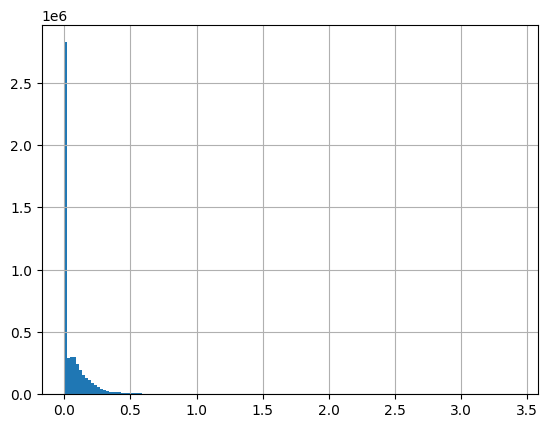

In [23]:
gt_minus_ideal_processing_time = (received_results_df['server_processing_time_measured'] - received_results_df['server_processing_time_ideal'])
gt_minus_ideal_processing_time = gt_minus_ideal_processing_time[gt_minus_ideal_processing_time != 0.0]
gt_minus_ideal_processing_time.hist(bins=150)

In [24]:
gt_minus_ideal_processing_time.max()

np.float64(3.4080391930402025)

In [25]:
gt_minus_ideal_processing_time.mean()

np.float64(0.07280017424616445)

In [26]:
sum(gt_minus_ideal_processing_time > gt_minus_ideal_processing_time.mean())

1598265

In [27]:
sum(gt_minus_ideal_processing_time > 0.1)

1258926

<Axes: >

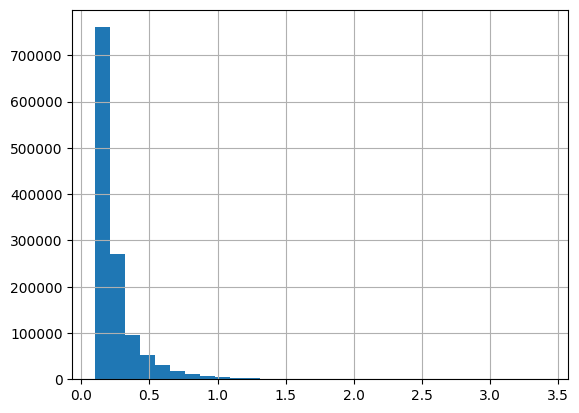

In [28]:
gt_minus_ideal_processing_time[gt_minus_ideal_processing_time > 0.1].hist(bins=30)

In [29]:
sum(gt_minus_ideal_processing_time > 0.2)

543668

<Axes: >

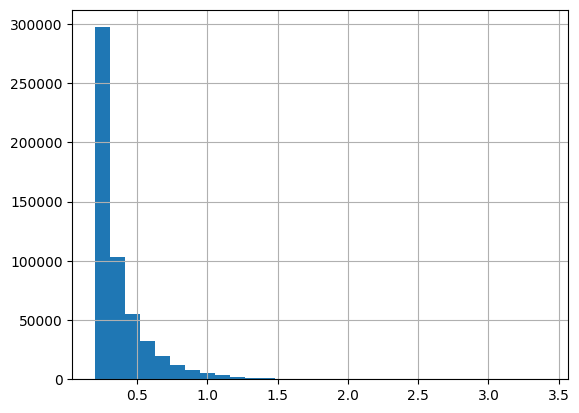

In [30]:
gt_minus_ideal_processing_time[gt_minus_ideal_processing_time > 0.2].hist(bins=30)

In [31]:
sum(gt_minus_ideal_processing_time > 0.3)

256389

<Axes: >

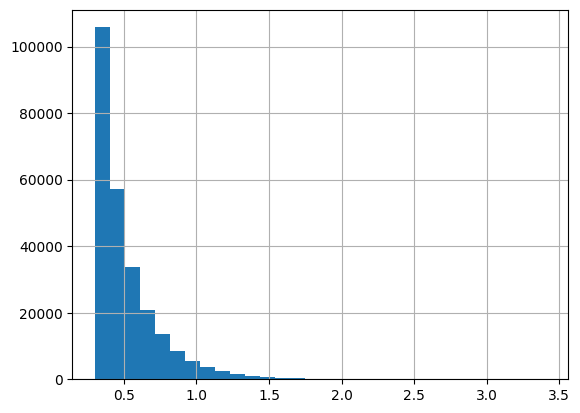

In [32]:
gt_minus_ideal_processing_time[gt_minus_ideal_processing_time > 0.3].hist(bins=30)

In [33]:
received_results_df.dtypes

client_labda                       category
server_mu                          category
alpha                              category
active_servers_num                    int64
request_id                            int64
server_processing_time_ideal        float64
time_untill_next_client             float64
sent_is_cpu                            bool
client_measured_time                float64
server_processing_time_measured     float64
dtype: object

In [34]:
draw_df = received_results_df.groupby(['alpha', 'active_servers_num'], observed=False)["client_measured_time"].mean()
draw_df = draw_df.dropna(axis=0, how='all')
draw_df = draw_df.reset_index()
draw_df['alpha'] = draw_df['alpha'].astype('float64')
draw_df

,alpha,active_servers_num,client_measured_time
0,0.0,1,176.454574
1,0.0,2,50.011522
2,0.0,3,12.646425
3,0.0,4,6.310494
4,0.0,5,3.551568
...,...,...,...
5388,1.0,699,1.263836
5389,1.0,700,1.318058
5390,1.0,998,1.413428
5391,1.0,999,1.214942


In [35]:
draw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5393 entries, 0 to 5392
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   alpha                 5393 non-null   float64
 1   active_servers_num    5393 non-null   int64  
 2   client_measured_time  5393 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 126.5 KB


In [36]:
BARIER = 25
unil_barier_df = draw_df[draw_df['active_servers_num'] < BARIER]
after_barier_df = draw_df[draw_df['active_servers_num'] >= BARIER]

final_draw_df = after_barier_df 
x, y, z = final_draw_df['alpha'], final_draw_df['active_servers_num'], final_draw_df['client_measured_time']

In [37]:
final_draw_df['active_servers_num'].min()

np.int64(25)

## Drawing section